In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
dog_rating_df = pd.read_csv('dog_rates_tweets.csv', parse_dates=['created_at'])

In [3]:
dog_rating_df['ratings'] = dog_rating_df['text'].str.extract(r'(\d+(\.\d+)?)/10')[0]

In [4]:
dog_rating_df = dog_rating_df.dropna(subset=['ratings'])
dog_rating_df['int_ratings'] = pd.to_numeric(dog_rating_df['ratings'], errors='coerce') # Source: https://stackoverflow.com/questions/31790287/convert-pandas-dataframe-column-from-string-to-int-based-on-conditional

In [5]:
dog_rating_df = dog_rating_df[dog_rating_df['int_ratings'] <= 25]
dog_rating_df = dog_rating_df[dog_rating_df['int_ratings'] >= 0]

Text(0, 0.5, 'Ratings')

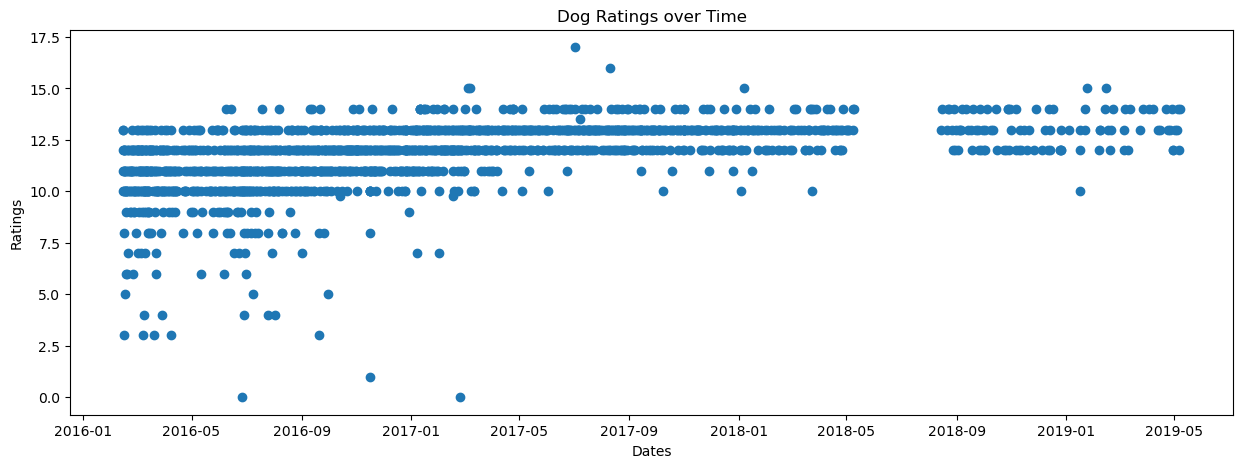

In [6]:
plt.figure(figsize=(15, 5))
plt.scatter(dog_rating_df['created_at'], dog_rating_df['int_ratings'])
plt.title('Dog Ratings over Time')
plt.xlabel('Dates')
plt.ylabel('Ratings')

In [7]:
def to_timestamp(dt):
    return dt.timestamp()

In [8]:
dog_rating_df['timestamp'] = dog_rating_df['created_at'].apply(to_timestamp)
dog_rating_df

,id,created_at,text,ratings,int_ratings,timestamp
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...,14,14.0,1.525910e+09
7,993889039714578432,2018-05-08 16:23:07,This is Manny. He hasn’t seen your croissant. ...,13,13.0,1.525797e+09
8,993629544463642624,2018-05-07 23:11:58,This is Libby. She leap. 14/10\n(IG: libbythef...,14,14.0,1.525735e+09
24,992198572664860672,2018-05-04 00:25:48,This is Rosie. She thought Coachella was this ...,13,13.0,1.525394e+09
30,991744041351090177,2018-05-02 18:19:39,This is Riley. He’ll be your chauffeur this ev...,13,13.0,1.525285e+09
...,...,...,...,...,...,...
7363,1032725635888803841,2018-08-23 20:25:53,This is Noodles. He had brain surgery earlier ...,14,14.0,1.535056e+09
7369,1032310288652152832,2018-08-22 16:55:26,This is Pingo and Nina. They are believed to b...,14,14.0,1.534957e+09
7381,1031696422813544448,2018-08-21 00:16:09,This is Nikita. She got caught in some wild fl...,13,13.0,1.534811e+09
7431,1029767403545288706,2018-08-15 16:30:55,This is Winston. He came home for the first ti...,14,14.0,1.534351e+09


In [9]:
best_fit_line = linregress(dog_rating_df['timestamp'], dog_rating_df['int_ratings'])
print(best_fit_line.slope)
print(best_fit_line.intercept)

3.515929974847721e-08
-40.46415480898916


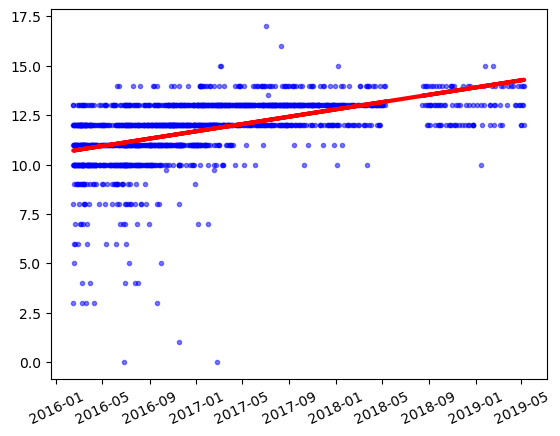

In [10]:
plt.xticks(rotation=25)
plt.plot(dog_rating_df['created_at'], dog_rating_df['int_ratings'], 'b.', alpha=0.5)
plt.plot(dog_rating_df['created_at'], dog_rating_df['timestamp']*best_fit_line.slope + best_fit_line.intercept, 'r-', linewidth=3)
plt.show()